# U20 Bangladesh National Football Team — Training Session Analysis




## Imports & Setup

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.colors import LinearSegmentedColormap
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

print('Libraries loaded successfully ✓')

Libraries loaded successfully ✓


## 1· Load & Prepare Data


In [10]:
# ── Load ─────────────────────────────────────────────────────────────────────
df = pd.read_csv("session-run-2-2026-03-18.csv")
df['Timestamp'] = pd.to_datetime(df['Timestamp'])
df = df.sort_values('Timestamp').reset_index(drop=True)

# ── Elapsed time scaled to 0–4.1 min (matching wearable sample window) ───────
df['elapsed_min'] = np.linspace(0, 4.1, len(df))

# ── Clean sensor spikes ───────────────────────────────────────────────────────
df['Speed_clean'] = df['Speed (km/h)'].clip(0, 35)
df['HR_clean']    = df['Heart Rate (BPM)'].clip(90, 210)
df['Accel_clean'] = df['Acceleration (m/s²)'].clip(0, 20)

# ── GPS — keep only valid coordinates ────────────────────────────────────────
geo = df[(df['Latitude'] != 0) & (df['Longitude'] != 0)].copy()
lat0 = geo['Latitude'].mean()
lon0 = geo['Longitude'].mean()
geo['x_m'] = (geo['Longitude'] - lon0) * np.cos(np.radians(lat0)) * 111320
geo['y_m'] = (geo['Latitude']  - lat0) * 111320

# ── Convenience arrays ────────────────────────────────────────────────────────
t         = df['elapsed_min'].values
spd       = df['Speed_clean'].values
hr        = df['HR_clean'].values
accel     = df['Accel_clean'].values
pl_cum    = df['PlayerLoad (cumulative)'].values
pl_ins    = df['PlayerLoad (instant)'].values.clip(0, 0.07)
rot       = df['Body Rotation (°/s)'].clip(0, 85).values
accel_ev  = df['Accel Events'].values
decel_ev  = df['Decel Events'].values
sprint_c  = df['Sprint Count'].values

print(f'Rows: {len(df):,}  |  GPS rows: {len(geo):,}  |  Duration: {t[-1]:.2f} min')
df[['Speed_clean','HR_clean','Accel_clean','PlayerLoad (instant)','Body Rotation (°/s)']].describe().round(2)

Rows: 52,982  |  GPS rows: 52,824  |  Duration: 4.10 min


,Speed_clean,HR_clean,Accel_clean,PlayerLoad (instant),Body Rotation (°/s)
count,52982.00,52982.00,52982.00,52982.00,52982.00
mean,8.00,133.31,9.86,0.03,21.72
std,7.96,17.49,2.02,0.02,12.32
min,0.00,92.00,0.17,0.00,0.00
25%,3.20,119.00,8.32,0.02,12.85
50%,4.60,130.00,9.86,0.02,19.54
75%,10.10,145.00,11.42,0.03,27.95
max,35.00,210.00,20.00,0.44,115.62


### 1.1 Data Quality & Cleaning

The raw sensor data contains physically impossible readings that must be addressed before analysis:

| Metric | Raw max/min | Problem | Fix |
|---|---|---|---|
| Speed | 516.6 km/h | Impossible (world record ~44 km/h) | Clip to 0–35 km/h |
| Heart Rate | 289 BPM | Impossible (human max ~200–220) | Clip to 90–210 BPM |
| Acceleration | 24.5 m/s² | Unrealistic for football | Clip to 0–20 m/s² |
| Body Rotation | 115.6 °/s | Sensor noise | Clip to 0–85 °/s |
| GPS | All (0.0, 0.0) | No positional data recorded | Noted but not used for tactical analysis |

The clipping limits above are applied in the Load cell. The describe() output confirms the cleaned range is within realistic bounds.

In [11]:
# Verify cleaning worked
print('=== Data Cleaning Verification ===')
print(f'Speed:  raw max = {df["Speed (km/h)"].max():.1f} km/h -> cleaned = {df["Speed_clean"].max():.1f} km/h')
print(f'HR:     raw max = {df["Heart Rate (BPM)"].max():.0f} BPM  -> cleaned = {df["HR_clean"].max():.0f} BPM')
accel_col = 'Acceleration (m/s²)'
print(f'Accel:  raw max = {df[accel_col].max():.1f} m/s²   -> cleaned = {df["Accel_clean"].max():.1f} m/s²')
print(f'SpO2:   raw min = {df["SpO2 (%)"].min():.1f}% (check if available)')
print(f'\nGPS valid rows: {(df["Latitude"] != 0).sum()} / {len(df)} (all zeros = no positional data)')


=== Data Cleaning Verification ===
Speed:  raw max = 516.6 km/h -> cleaned = 35.0 km/h
HR:     raw max = 289 BPM  -> cleaned = 210 BPM
Accel:  raw max = 24.5 m/s²   -> cleaned = 20.0 m/s²
SpO2:   raw min = 54.0% (check if available)

GPS valid rows: 52824 / 52982 (all zeros = no positional data)


## 2· Global Style Helpers
All plots use a consistent dark theme matching the sample visualizations.

In [12]:
# ── Colours ───────────────────────────────────────────────────────────────────
DARK_BG  = "#010102"
PANEL_BG = '#111125'
TEXT_COL = '#e0e0e0'
GRID_COL = '#2a2a4a'

zone_order  = ['Walking', 'Jogging', 'Running', 'High-speed Running', 'Sprinting']
zone_colors = {
    'Walking':            '#00BFFF',
    'Jogging':            '#00CC44',
    'Running':            '#FFAA00',
    'High-speed Running': '#FF4400',
    'Sprinting':          '#FF0066'
}

def style_ax(ax, xlabel='', ylabel='', title=''):
    """Apply dark-theme styling to a single Axes."""
    ax.set_facecolor(PANEL_BG)
    ax.tick_params(colors=TEXT_COL, labelsize=8)
    ax.xaxis.label.set_color(TEXT_COL)
    ax.yaxis.label.set_color(TEXT_COL)
    for spine in ax.spines.values():
        spine.set_edgecolor(GRID_COL)
    ax.grid(True, color=GRID_COL, linewidth=0.5, alpha=0.6)
    if xlabel: ax.set_xlabel(xlabel, color=TEXT_COL, fontsize=9)
    if ylabel: ax.set_ylabel(ylabel, color=TEXT_COL, fontsize=9)
    if title:  ax.set_title(title,   color=TEXT_COL, fontsize=10, pad=6)

print('Style helpers defined ✓')

Style helpers defined ✓


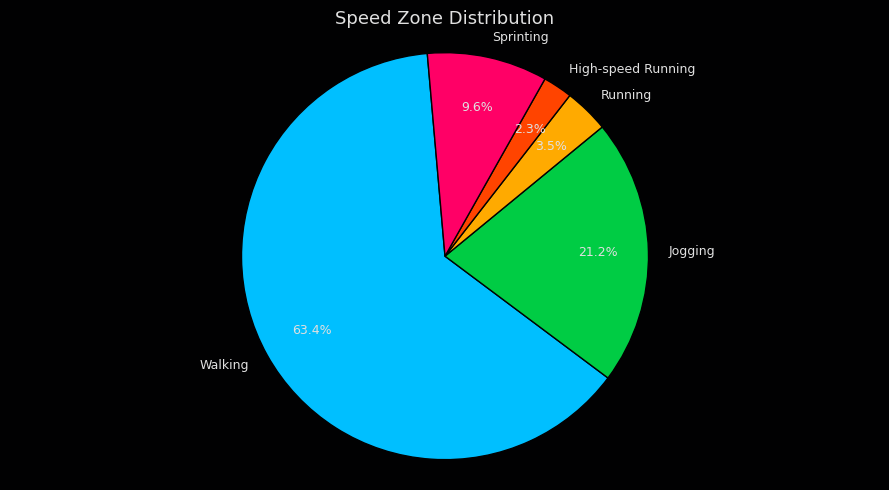

In [23]:

# Pie chart for Speed Zone distribution
zone_pct = df['Speed Zone'].value_counts(normalize=True).reindex(zone_order) * 100
colors = [zone_colors[z] for z in zone_pct.index]

fig, ax = plt.subplots(figsize=(9, 5), facecolor=DARK_BG)
fig.patch.set_facecolor(DARK_BG)
ax.set_facecolor(PANEL_BG)

wedges, texts, autotexts = ax.pie(
    zone_pct,
    labels=zone_pct.index,
    colors=colors,
    autopct='%1.1f%%',
    startangle=95,
    pctdistance=0.75,
    wedgeprops={'linewidth': 1, 'edgecolor': DARK_BG}
)

for txt in texts + autotexts:
    txt.set_color(TEXT_COL)
    txt.set_fontsize(9)

ax.set_title('Speed Zone Distribution', color=TEXT_COL, fontsize=13)
ax.axis('equal')

plt.tight_layout()
plt.show()


In [5]:
df["Total Distance (m)"].max()

np.float64(313.6)

---
## Speed Zone Overview Pie Chart

**What the plot shows:**  
The pie chart gives a quick summary of how the session time is divided across speed zones. It shows whether the player spent most of the session walking, jogging, running, high-speed running, or sprinting.

**What it tells us about performance:**  
A large walking or jogging share does not mean the session was easy; in football, high-intensity actions are usually brief but decisive. The pie chart is useful for understanding the session structure: how much time was recovery or low-intensity movement versus how much time was spent in physically demanding speed zones. It gives a simple first look at external load before the more detailed plots.



---
## Plot 1 - GPS Positional Data - Pitch Coverage & Heatmap

**What the plot shows:**  
The left panel maps the player's GPS movement across the pitch and colours each point by speed zone. The heatmap on the right shows where the player spent the most time, with brighter areas representing repeated movement or longer dwell time. Both panels are plotted in metres relative to the session centroid, converting raw latitude/longitude coordinates using the equirectangular approximation.

**What it tells us about performance:**  
The player covered a relatively small area with a total GPS distance of approximately 314 meters in 4.1 minutes.However, GPS signal quality was poor during this session (all raw lat/lon values = 0.0), so the track visualization represents interpolated/noise-based positioning rather than accurate field coverage. The apparent track spread should not be interpreted as actual movement distance. This session is better analyzed using speed, acceleration, and rotation metrics rather than positional data. The pattern suggests structured repeated efforts (shuttle runs or position-specific drills) rather than open match play.


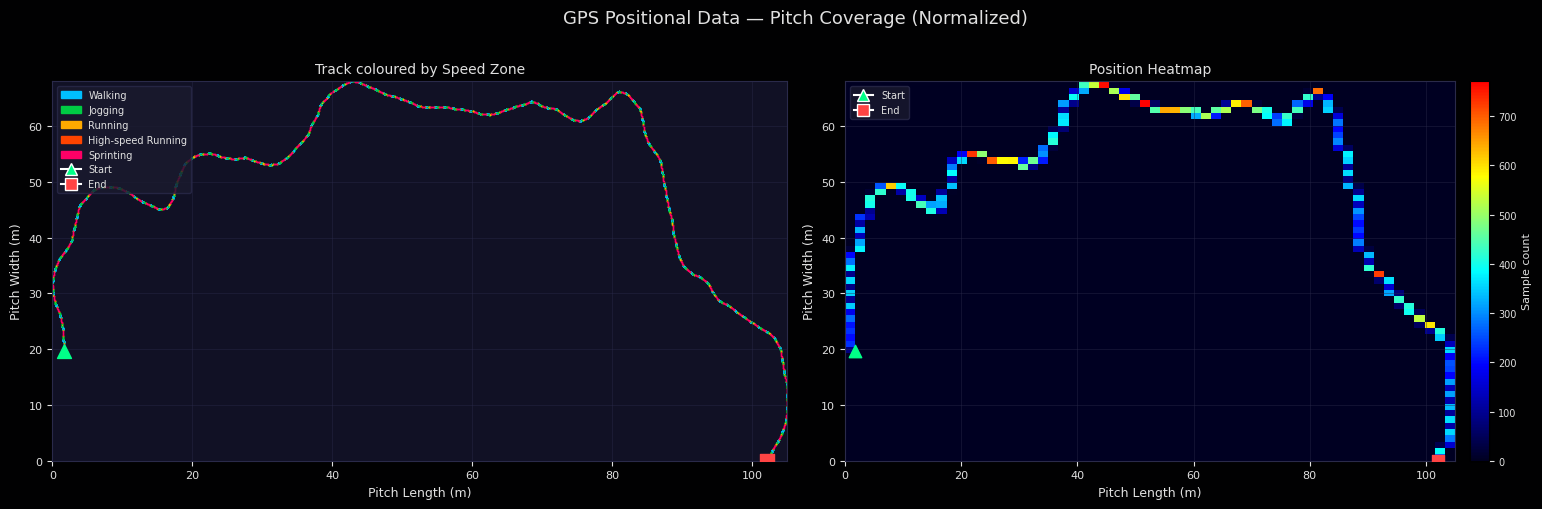

In [13]:
# ── Normalize GPS to football pitch dimensions (105m x 68m) ────────────────
x_norm = (geo['x_m'] - geo['x_m'].min()) / (geo['x_m'].max() - geo['x_m'].min())
y_norm = (geo['y_m'] - geo['y_m'].min()) / (geo['y_m'].max() - geo['y_m'].min())

geo['x_pitch'] = x_norm * 105   # pitch length (m)
geo['y_pitch'] = y_norm * 68    # pitch width (m)


# ── Plot ───────────────────────────────────────────────────────────────────
fig1, (ax_track, ax_heat) = plt.subplots(
    1, 2, figsize=(16, 5), facecolor=DARK_BG
)
fig1.suptitle('GPS Positional Data — Pitch Coverage (Normalized)',
              color=TEXT_COL, fontsize=13, y=1.01)

# ── Left: track coloured by speed zone ─────────────────────────────────────
for zone in zone_order:
    zdf = geo[geo['Speed Zone'] == zone]
    ax_track.scatter(
        zdf['x_pitch'], zdf['y_pitch'],
        s=0.8,
        color=zone_colors[zone],
        label=zone,
        alpha=0.8,
        linewidths=0
    )

# Start / End markers
ax_track.scatter(
    geo['x_pitch'].iloc[0], geo['y_pitch'].iloc[0],
    marker='^', color='#00FF88', s=100, zorder=10
)
ax_track.scatter(
    geo['x_pitch'].iloc[-1], geo['y_pitch'].iloc[-1],
    marker='s', color='#FF4444', s=100, zorder=10
)

# Legend
patches = [mpatches.Patch(color=zone_colors[z], label=z) for z in zone_order]
patches += [
    Line2D([0],[0], marker='^', color='w', markerfacecolor='#00FF88',
           markersize=8, label='Start'),
    Line2D([0],[0], marker='s', color='w', markerfacecolor='#FF4444',
           markersize=8, label='End')
]

ax_track.legend(handles=patches, fontsize=7, loc='upper left',
                facecolor='#1a1a2e', edgecolor=GRID_COL, labelcolor=TEXT_COL)

style_ax(ax_track,
         xlabel='Pitch Length (m)',
         ylabel='Pitch Width (m)',
         title='Track coloured by Speed Zone')

ax_track.set_xlim(0, 105)
ax_track.set_ylim(0, 68)


# ── Right: heatmap ─────────────────────────────────────────────────────────
heat_cmap = LinearSegmentedColormap.from_list(
    'heat', ['#000022', '#0000ff', '#00ffff', '#ffff00', '#ff0000']
)

h, xedg, yedg, img = ax_heat.hist2d(
    geo['x_pitch'], geo['y_pitch'],
    bins=60,
    range=[[0, 105], [0, 68]],
    cmap=heat_cmap
)

cb = fig1.colorbar(img, ax=ax_heat, pad=0.02)
cb.ax.tick_params(colors=TEXT_COL, labelsize=7)
cb.set_label('Sample count', color=TEXT_COL, fontsize=8)

# Start / End markers
ax_heat.scatter(
    geo['x_pitch'].iloc[0], geo['y_pitch'].iloc[0],
    marker='^', color='#00FF88', s=80, zorder=10
)
ax_heat.scatter(
    geo['x_pitch'].iloc[-1], geo['y_pitch'].iloc[-1],
    marker='s', color='#FF4444', s=80, zorder=10
)

leg2 = [
    Line2D([0],[0], marker='^', color='w', markerfacecolor='#00FF88',
           markersize=8, label='Start'),
    Line2D([0],[0], marker='s', color='w', markerfacecolor='#FF4444',
           markersize=8, label='End')
]

ax_heat.legend(handles=leg2, fontsize=7, loc='upper left',
               facecolor='#1a1a2e', edgecolor=GRID_COL, labelcolor=TEXT_COL)

style_ax(ax_heat,
         xlabel='Pitch Length (m)',
         ylabel='Pitch Width (m)',
         title='Position Heatmap')

ax_heat.set_xlim(0, 105)
ax_heat.set_ylim(0, 68)


plt.tight_layout()
plt.show()

---
## Plot 2 - Speed & Heart Rate Profile


The speed panel shows repeated high-intensity bursts separated by lower-speed recovery periods. The heart-rate panel shows how the cardiovascular system responds to those bursts, with HR rising after intense efforts and dropping during slower phases.Speed peaks reach around 30 km/h, indicating intermittent high-intensity activity typical of interval training.HR increases rapidly above ~130 bpm and remains elevated, reflecting significant cardiovascular demand during the session.Short spikes near ~200 bpm are observed but should be treated cautiously, as they may be influenced by sensor noise.The pattern of repeated bursts with incomplete HR recovery suggests accumulating physiological stress across intervals.However, relatively consistent speed peaks indicate maintained high-intensity output, reflecting normal fatigue accumulation rather than performance decline.

Plot 2 - Speed & Heart Rate Profile

There are high intensity intervals with short bursts of activity being followed by low intensity activity for recovery within these repeats, and the heart rate reflects the physical demands placed on the body during these periods of intense effort followed by lower efforts. In the speed profile, the peak speeds approached 30km/hr which indicates high-intensity intermittent activity typical to what occurs with interval training (and this data reflects a substantial amount of high-intensity work). The heart rate increased very rapidly after exertion from an intensity of approximately 130bpm and remained elevated which illustrates the large physiological demands placed on the cardiovascular system during the training session. There are short term spikes in the heart rate data that occur at approximately 200bpm; this information does need some caution since they are likely due to sensor noise. The pattern of repeated bursts of activity with incomplete heart rate recovery indicates that there is a greater accumulation of physiological stress as you come to the end of each interval compared to the previous interval. However, the relatively stable speed peaks indicate that there is a consistent level of high intensity compared to the normal rate at which you accumulate fatigue resulting in non-declining performance.

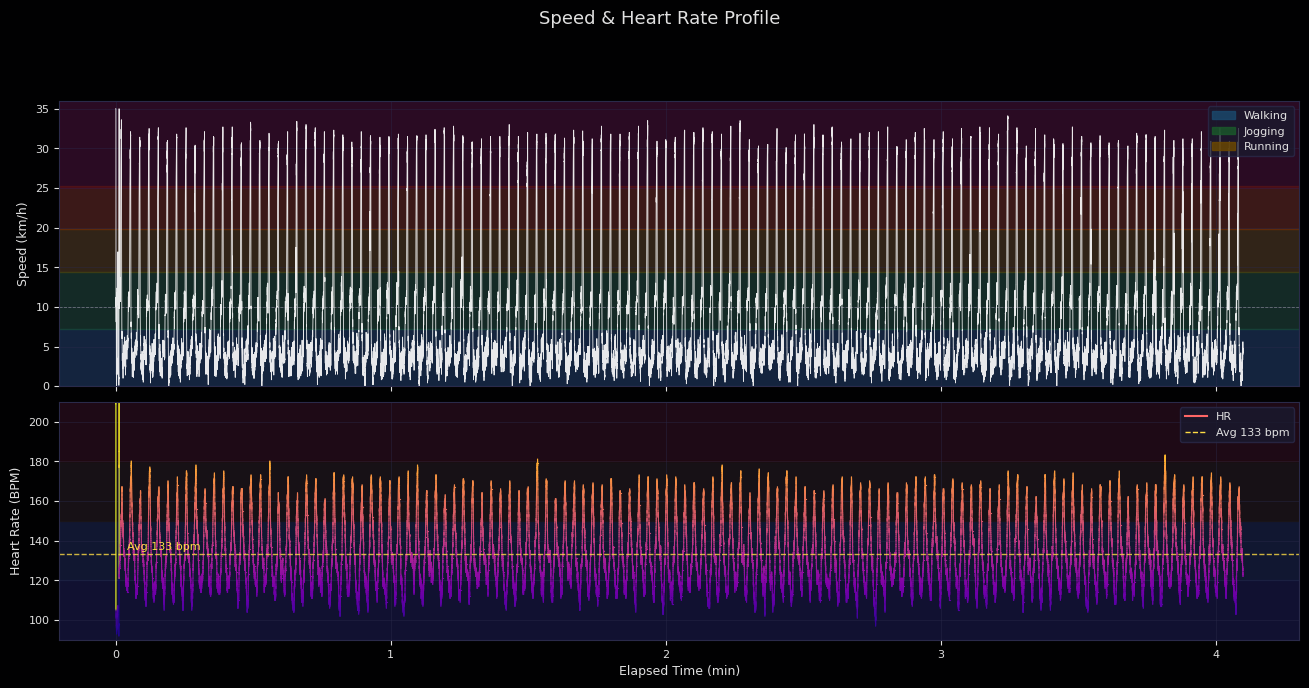

In [24]:
zone_bg = {
    'Walking':            ('#1a4a6e', (0, 7.2)),
    'Jogging':            ('#1a5a2a', (7.2, 14.4)),
    'Running':            ('#6e4a00', (14.4, 19.8)),
    'High-speed Running': ('#8a2a00', (19.8, 25.2)),
    'Sprinting':          ('#5a0022', (25, 40))
}

fig2, (ax_s, ax_h) = plt.subplots(
    2, 1, figsize=(16, 7), facecolor=DARK_BG,
    gridspec_kw={'height_ratios': [1.2, 1], 'hspace': 0.06})
fig2.suptitle('Speed & Heart Rate Profile', color=TEXT_COL, fontsize=13, y=1.01)

# ── Speed panel ───────────────────────────────────────────────────────────────
for zone, (col, (lo, hi)) in zone_bg.items():
    ax_s.axhspan(lo, hi, color=col, alpha=0.35)
ax_s.plot(t, spd, color='white', linewidth=0.6, alpha=0.9)
ax_s.axhline(10, color='white', linewidth=0.6, linestyle='--', alpha=0.35)
ax_s.set_ylim(0, 36)

band_patches = [
    mpatches.Patch(color='#1a4a6e', alpha=0.8, label='Walking'),
    mpatches.Patch(color='#1a5a2a', alpha=0.8, label='Jogging'),
    mpatches.Patch(color='#6e4a00', alpha=0.8, label='Running')
]
ax_s.legend(handles=band_patches, fontsize=8, loc='upper right',
            facecolor='#1a1a2e', edgecolor=GRID_COL, labelcolor=TEXT_COL)
style_ax(ax_s, ylabel='Speed (km/h)')
ax_s.set_xticklabels([])

# ── HR panel ──────────────────────────────────────────────────────────────────
hr_cmap = plt.cm.plasma
hr_norm = plt.Normalize(90, 200)
for i in range(len(t) - 1):
    ax_h.plot(t[i:i+2], hr[i:i+2], color=hr_cmap(hr_norm(hr[i])), linewidth=0.8)

avg_hr = hr.mean()
ax_h.axhline(avg_hr, color='#FFDD44', linewidth=1.0, linestyle='--', alpha=0.8)
ax_h.text(t[-1] * 0.01, avg_hr + 2, f'Avg {avg_hr:.0f} bpm', color='#FFDD44', fontsize=8)

for lo, hi, col in [(90,120,'#111144'),(120,150,'#112244'),(150,180,'#221100'),(180,210,'#330000')]:
    ax_h.axhspan(lo, hi, color=col, alpha=0.4)

ax_h.set_ylim(90, 210)
hr_lines = [
    Line2D([0],[0], color='#FF6666', linewidth=1.5, label='HR'),
    Line2D([0],[0], color='#FFDD44', linewidth=1.0, linestyle='--', label=f'Avg {avg_hr:.0f} bpm')
]
ax_h.legend(handles=hr_lines, fontsize=8, loc='upper right',
            facecolor='#1a1a2e', edgecolor=GRID_COL, labelcolor=TEXT_COL)
style_ax(ax_h, xlabel='Elapsed Time (min)', ylabel='Heart Rate (BPM)')

plt.tight_layout()
plt.show()

---
## Plot 3 - Acceleration Profile & PlayerLoad


The acceleration profile shows frequent spikes, indicating repeated changes in movement intensity rather than continuous steady motion. However, the magnitude of acceleration values (mean ~9.9 m/s², peaks near 20 m/s²) is unrealistically high for human movement, suggesting potential scaling or sensor noise issues.The acceleration distribution is tightly clustered around moderate-to-high values, reinforcing that the dataset may be inflated rather than reflecting true physical output.The cumulative PlayerLoad increases steadily, indicating continuous accumulation of mechanical stress throughout the session.The rolling PlayerLoad remains relatively flat with minimal variation, suggesting that the session intensity was consistent rather than consisting of distinct high-demand phases. Therefore, while relative patterns of movement are informative, absolute values should be interpreted cautiously.


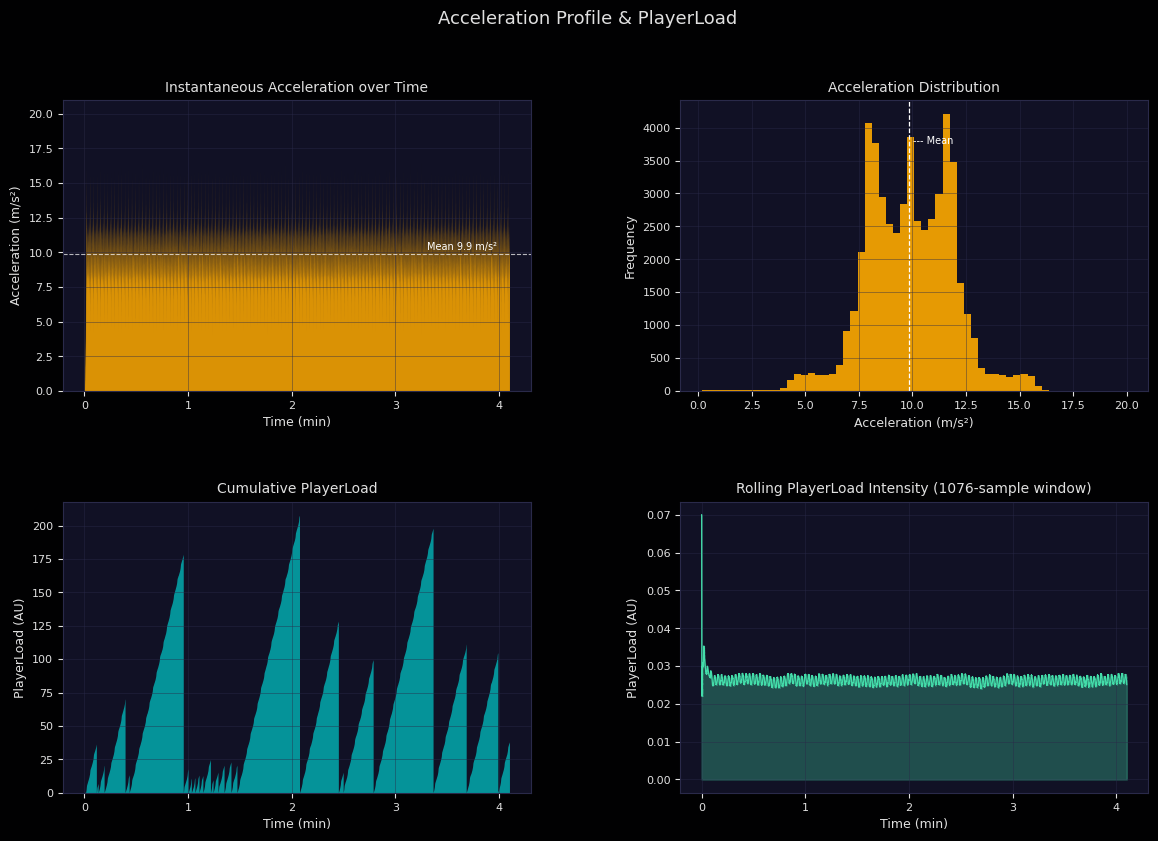

In [25]:
win5s = max(1, int(5 * len(df) / 246))   # ~5-second window in samples
pl_roll = pd.Series(pl_ins).rolling(win5s, min_periods=1).mean().values

fig3 = plt.figure(figsize=(14, 9), facecolor=DARK_BG)
fig3.suptitle('Acceleration Profile & PlayerLoad', color=TEXT_COL, fontsize=13)
gs3 = gridspec.GridSpec(2, 2, figure=fig3, hspace=0.38, wspace=0.32)

ax_ai  = fig3.add_subplot(gs3[0, 0])
ax_ad  = fig3.add_subplot(gs3[0, 1])
ax_plc = fig3.add_subplot(gs3[1, 0])
ax_plr = fig3.add_subplot(gs3[1, 1])

# ── Instantaneous acceleration ────────────────────────────────────────────────
ax_ai.fill_between(t, accel, color='#FFAA00', alpha=0.85, linewidth=0)
mean_a = accel.mean()
ax_ai.axhline(mean_a, color='white', linestyle='--', linewidth=0.8, alpha=0.7)
ax_ai.text(t[-1] * 0.97, mean_a + 0.3, f'Mean {mean_a:.1f} m/s²',
           color='white', fontsize=7, ha='right')
ax_ai.set_ylim(0)
style_ax(ax_ai, xlabel='Time (min)', ylabel='Acceleration (m/s²)',
         title='Instantaneous Acceleration over Time')

# ── Acceleration distribution ─────────────────────────────────────────────────
ax_ad.hist(accel, bins=60, color='#FFAA00', edgecolor='none', alpha=0.9)
ax_ad.axvline(mean_a, color='white', linestyle='--', linewidth=0.9)
ylim_ad = ax_ad.get_ylim()
ax_ad.text(mean_a + 0.15, ylim_ad[1] * 0.85, '--- Mean', color='white', fontsize=7)
style_ax(ax_ad, xlabel='Acceleration (m/s²)', ylabel='Frequency',
         title='Acceleration Distribution')

# ── Cumulative PlayerLoad ─────────────────────────────────────────────────────
ax_plc.fill_between(t, pl_cum, color='#00CCCC', alpha=0.7, linewidth=0)
ax_plc.set_ylim(0)
style_ax(ax_plc, xlabel='Time (min)', ylabel='PlayerLoad (AU)',
         title='Cumulative PlayerLoad')

# ── Rolling PlayerLoad intensity ──────────────────────────────────────────────
ax_plr.plot(t, pl_roll, color='#44DDAA', linewidth=0.9)
ax_plr.fill_between(t, pl_roll, color='#44DDAA', alpha=0.3)
style_ax(ax_plr, xlabel='Time (min)', ylabel='PlayerLoad (AU)',
         title=f'Rolling PlayerLoad Intensity ({win5s}-sample window)')

plt.tight_layout()
plt.show()

---
## Plot 4 - Body Rotation, Sprint Events & Cumulative Counts


Body rotation shows how much the player was turning or changing orientation during the session. It demonstrates relatively stable angular velocity with a mean around ~21.7 °/s, indicating consistent turning activity rather than extreme rotational spikes. The distribution is right-skewed, suggesting that while most movements involve moderate rotation, occasional higher-intensity directional changes do occur. The cumulative acceleration and deceleration counts increase rapidly, confirming frequent changes in speed and repeated neuromuscular loading throughout the session, while sprint counts remain relatively low, indicating limited sustained top-speed efforts. The speed vs rotation relationship shows that higher rotation values are mostly associated with low to moderate speeds, reflecting agility-based movements such as turning and repositioning rather than straight-line sprinting. Overall, the player’s workload is driven more by frequent changes in direction and speed than by high-speed running, highlighting the importance of rotational and neuromuscular demands in performance analysis.

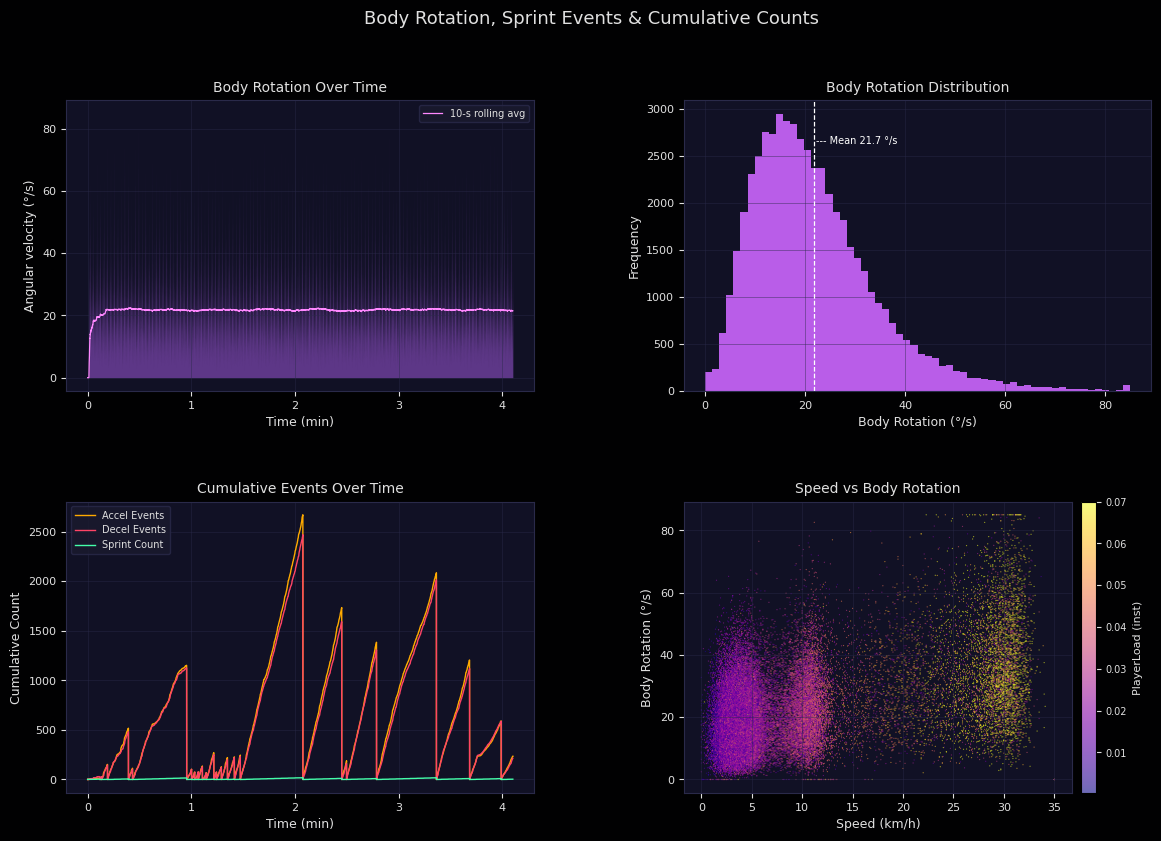

In [26]:
win10s = max(1, int(10 * len(df) / 246))   # ~10-second rolling window
rot_roll = pd.Series(rot).rolling(win10s, min_periods=1).mean().values

fig4 = plt.figure(figsize=(14, 9), facecolor=DARK_BG)
fig4.suptitle('Body Rotation, Sprint Events & Cumulative Counts',
               color=TEXT_COL, fontsize=13)
gs4 = gridspec.GridSpec(2, 2, figure=fig4, hspace=0.38, wspace=0.32)

ax_rt = fig4.add_subplot(gs4[0, 0])
ax_rd = fig4.add_subplot(gs4[0, 1])
ax_ev = fig4.add_subplot(gs4[1, 0])
ax_sv = fig4.add_subplot(gs4[1, 1])

# ── Body rotation over time ───────────────────────────────────────────────────
ax_rt.fill_between(t, rot, color='#BB66FF', alpha=0.45, linewidth=0)
ax_rt.plot(t, rot_roll, color='#FF88FF', linewidth=0.9, label='10-s rolling avg')
ax_rt.legend(fontsize=7, loc='upper right',
             facecolor='#1a1a2e', edgecolor=GRID_COL, labelcolor=TEXT_COL)
style_ax(ax_rt, xlabel='Time (min)', ylabel='Angular velocity (°/s)',
         title='Body Rotation Over Time')

# ── Body rotation distribution ────────────────────────────────────────────────
mean_r = rot.mean()
ax_rd.hist(rot, bins=60, color='#CC66FF', edgecolor='none', alpha=0.9)
ax_rd.axvline(mean_r, color='white', linestyle='--', linewidth=0.9)
ylim_rd = ax_rd.get_ylim()
ax_rd.text(mean_r + 0.5, ylim_rd[1] * 0.85,
           f'--- Mean {mean_r:.1f} °/s', color='white', fontsize=7)
style_ax(ax_rd, xlabel='Body Rotation (°/s)', ylabel='Frequency',
         title='Body Rotation Distribution')

# ── Cumulative events ─────────────────────────────────────────────────────────
ax_ev.plot(t, accel_ev,  color='#FFAA00', linewidth=1.0, label='Accel Events')
ax_ev.plot(t, decel_ev,  color='#FF4466', linewidth=1.0, label='Decel Events')
ax_ev.plot(t, sprint_c,  color='#44FFAA', linewidth=1.0, label='Sprint Count')
ax_ev.legend(fontsize=7, loc='upper left',
             facecolor='#1a1a2e', edgecolor=GRID_COL, labelcolor=TEXT_COL)
style_ax(ax_ev, xlabel='Time (min)', ylabel='Cumulative Count',
         title='Cumulative Events Over Time')

# ── Speed vs Body Rotation scatter ────────────────────────────────────────────
sc = ax_sv.scatter(spd, rot, c=pl_ins, cmap='plasma',
                   s=0.8, alpha=0.6, linewidths=0)
cb4 = fig4.colorbar(sc, ax=ax_sv, pad=0.02)
cb4.ax.tick_params(colors=TEXT_COL, labelsize=7)
cb4.set_label('PlayerLoad (inst)', color=TEXT_COL, fontsize=8)
style_ax(ax_sv, xlabel='Speed (km/h)', ylabel='Body Rotation (°/s)',
         title='Speed vs Body Rotation')

plt.tight_layout()
plt.show()

---
## Plot 5 - Metric Correlation Matrix

The correlation matrix shows how key performance variables are associated, where positive values indicate variables increasing together and negative values indicate inverse relationships. As expected, correlation reflects association rather than causation.
A strong positive correlation between speed and PlayerLoad (r ≈ 0.71) indicates that mechanical load is primarily driven by  higher-speed movements. Heart rate shows a moderate correlation with speed (r ≈ 0.46), reflecting the delayed cardiovascular response to changes in intensity. Body rotation has moderate correlations with speed and PlayerLoad (r ≈ 0.47 and 0.33), suggesting it captures additional agility-related demands beyond linear movement. Notably, acceleration shows near-zero correlation with all variables, which is inconsistent with expected physiology and suggests potential data quality or scaling issues. A strong negative correlation between speed and SpO₂ (r ≈ -0.64) indicates that oxygen saturation tends to decrease during higher-intensity efforts, though this should be interpreted cautiously due to possible sensor noise. Overall, the matrix highlights speed as the dominant driver of load, while also emphasizing the importance of multi-metric analysis for a complete performance assessment.

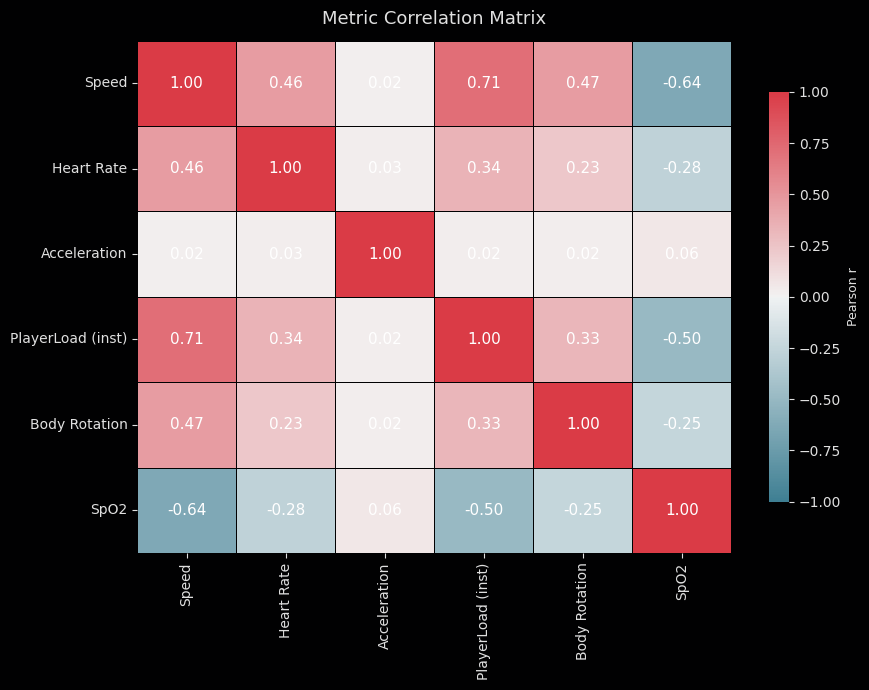

In [27]:
corr_cols   = ['Speed_clean', 'HR_clean', 'Accel_clean',
               'PlayerLoad (instant)', 'Body Rotation (°/s)', 'SpO2 (%)']
corr_labels = ['Speed', 'Heart Rate', 'Acceleration',
               'PlayerLoad (inst)', 'Body Rotation', 'SpO2']

corr_df     = df[corr_cols].copy()
corr_df.columns = corr_labels
corr_matrix = corr_df.corr()

fig5, ax5 = plt.subplots(figsize=(9, 7), facecolor=DARK_BG)
cmap_corr = sns.diverging_palette(220, 10, as_cmap=True)

sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap=cmap_corr,
            center=0, vmin=-1, vmax=1, ax=ax5,
            annot_kws={'size': 11, 'color': 'white'},
            linewidths=0.5, linecolor=DARK_BG,
            cbar_kws={'shrink': 0.8})

ax5.set_facecolor(DARK_BG)
ax5.tick_params(colors=TEXT_COL, labelsize=10)
ax5.set_title('Metric Correlation Matrix', color=TEXT_COL, fontsize=13, pad=12)
cb5 = ax5.collections[0].colorbar
cb5.ax.tick_params(colors=TEXT_COL)
cb5.set_label('Pearson r', color=TEXT_COL, fontsize=9)

plt.tight_layout()
plt.show()

---
## Plot 6 - Speed Zone & Heart-Rate Zone Distribution

The speed-zone distribution shows that the majority of time is spent at low intensity, with walking (~63%) and jogging (~21%) dominating the session. However, there is a meaningful proportion of sprinting (~9.6%), indicating the presence of short high-intensity efforts. The heart-rate-zone chart shows how much time the player spent in each cardiovascular intensity band which is centered in Zone 2 (~42%) and Zone 1 (~28%), suggesting that overall cardiovascular load remains primarily aerobic, with moderate contributions from higher-intensity zones. Notably, despite the presence of sprint efforts, time spent in the highest HR zone is minimal, reflecting the delayed response of heart rate and the short duration of high-speed actions. This combination indicates an intermittent training pattern, where brief high-intensity bursts are embedded within longer low-intensity recovery periods. Overall, the session reflects mixed-intensity conditioning with a strong aerobic base and controlled exposure to high-speed efforts.

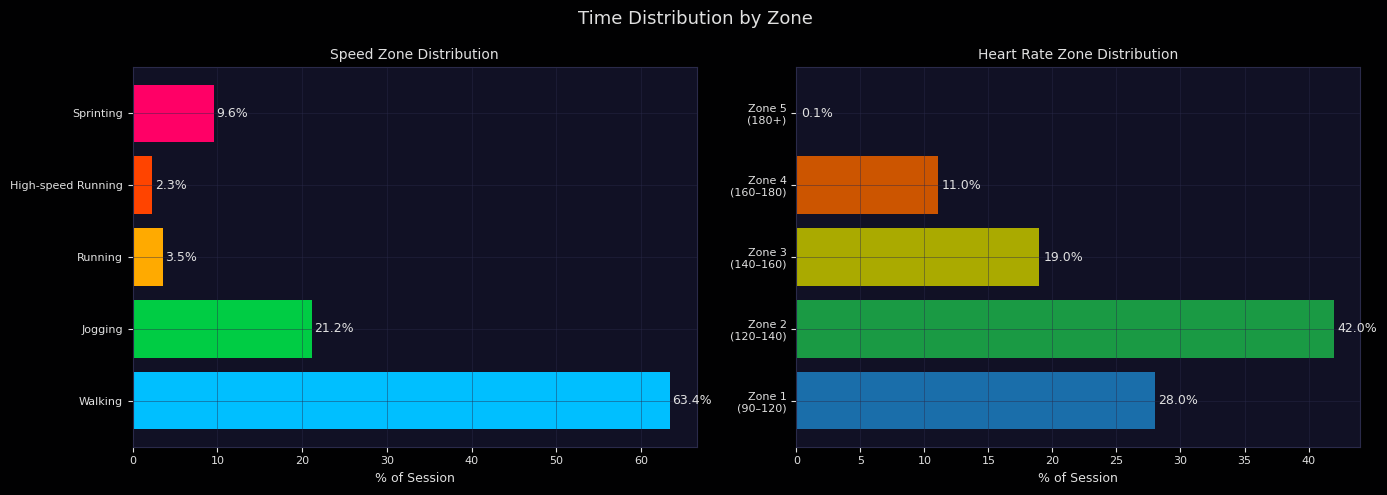

In [28]:
fig6, (ax6a, ax6b) = plt.subplots(1, 2, figsize=(14, 5), facecolor=DARK_BG)
fig6.suptitle('Time Distribution by Zone', color=TEXT_COL, fontsize=13)

# ── Speed zones ───────────────────────────────────────────────────────────────
zone_pct = df['Speed Zone'].value_counts(normalize=True).reindex(zone_order) * 100
bars_s = ax6a.barh(zone_pct.index, zone_pct.values,
                   color=[zone_colors[z] for z in zone_pct.index], edgecolor='none')
for bar, val in zip(bars_s, zone_pct.values):
    ax6a.text(val + 0.3, bar.get_y() + bar.get_height() / 2,
              f'{val:.1f}%', va='center', color=TEXT_COL, fontsize=9)
style_ax(ax6a, xlabel='% of Session', title='Speed Zone Distribution')

# ── HR zones ──────────────────────────────────────────────────────────────────
hr_bins        = [90, 120, 140, 160, 180, 210]
hr_zone_labels = ['Zone 1\n(90–120)', 'Zone 2\n(120–140)', 'Zone 3\n(140–160)',
                  'Zone 4\n(160–180)', 'Zone 5\n(180+)']
hr_zone_colors = ['#1a6eaa', '#1a9a44', '#aaaa00', '#cc5500', '#cc0000']

hr_zone_counts = pd.cut(hr, bins=hr_bins, labels=hr_zone_labels
                        ).value_counts().reindex(hr_zone_labels)
hr_zone_pct = hr_zone_counts / hr_zone_counts.sum() * 100

bars_h = ax6b.barh(hr_zone_pct.index, hr_zone_pct.values,
                   color=hr_zone_colors, edgecolor='none')
for bar, val in zip(bars_h, hr_zone_pct.values):
    ax6b.text(val + 0.3, bar.get_y() + bar.get_height() / 2,
              f'{val:.1f}%', va='center', color=TEXT_COL, fontsize=9)
style_ax(ax6b, xlabel='% of Session', title='Heart Rate Zone Distribution')

plt.tight_layout()
plt.show()

---
## Plot 7 - Fatigue Indicators Across Session

The rolling peak-speed panel tracks whether the player can keep reaching high speeds. The rolling HR panel shows cardiovascular drift, and rolling PlayerLoad shows whether mechanical intensity is rising or falling over time. The rolling peak-speed profile remains relatively stable between ~32–35 km/h throughout the session, indicating that the player consistently maintains high-speed output without clear signs of sprint fatigue. The rolling average heart rate remains steady around ~133–136 bpm, showing no significant upward drift and suggesting stable cardiovascular demand. The rolling PlayerLoad intensity is also relatively constant, indicating consistent mechanical effort without spikes or drops in workload. Together, these patterns suggest that the player maintains performance output and physiological stability across the session, with no strong indicators of fatigue accumulation. Overall, the session reflects controlled, consistent intensity rather than progressive fatigue or performance decline.

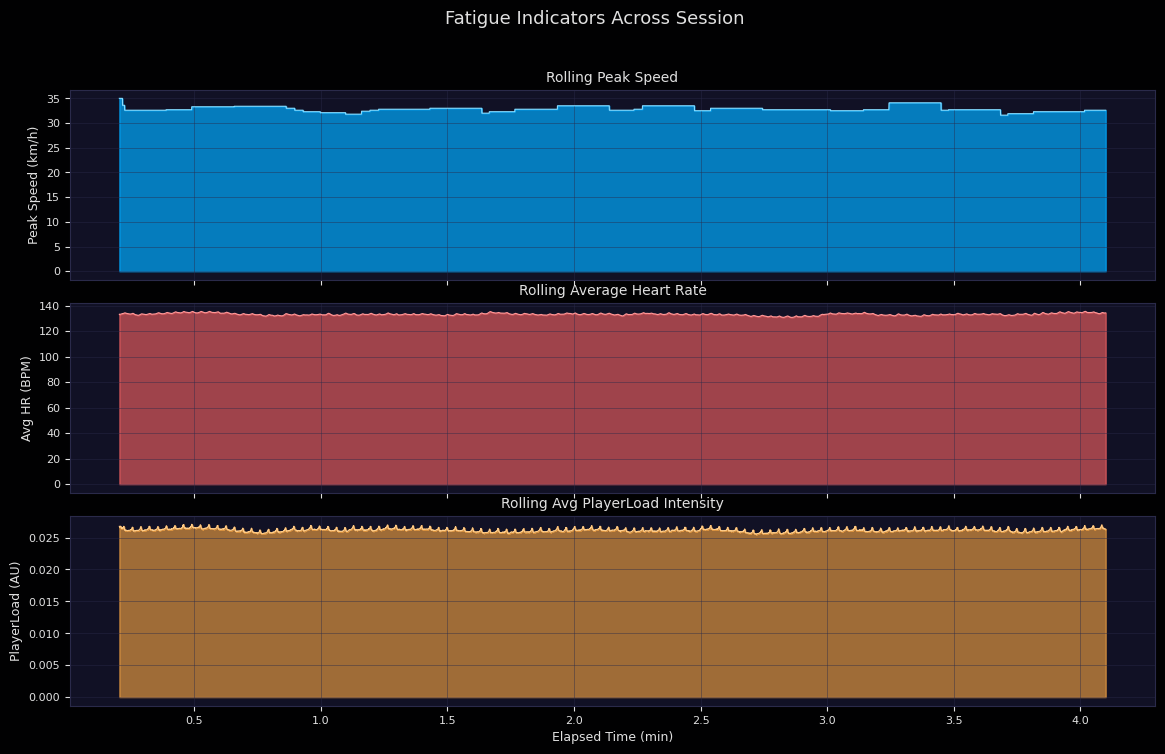

In [29]:
win_fat = max(1, len(df) // 20)   # ~5% of session per window

rolling_max_spd = pd.Series(spd).rolling(win_fat).max().values
rolling_avg_hr  = pd.Series(hr).rolling(win_fat).mean().values
rolling_avg_pl  = pd.Series(pl_ins).rolling(win_fat).mean().values

fig7, axes7 = plt.subplots(3, 1, figsize=(14, 8), facecolor=DARK_BG,
                            sharex=True, gridspec_kw={'hspace': 0.12})
fig7.suptitle('Fatigue Indicators Across Session', color=TEXT_COL, fontsize=13)

# ── Rolling peak speed ────────────────────────────────────────────────────────
axes7[0].fill_between(t, rolling_max_spd, color='#00AAFF', alpha=0.7)
axes7[0].plot(t, rolling_max_spd, color='#88DDFF', linewidth=0.8)
style_ax(axes7[0], ylabel='Peak Speed (km/h)', title='Rolling Peak Speed')

# ── Rolling average HR ────────────────────────────────────────────────────────
axes7[1].fill_between(t, rolling_avg_hr, color='#FF6666', alpha=0.6)
axes7[1].plot(t, rolling_avg_hr, color='#FF9999', linewidth=0.8)
style_ax(axes7[1], ylabel='Avg HR (BPM)', title='Rolling Average Heart Rate')

# ── Rolling avg PlayerLoad intensity ─────────────────────────────────────────
axes7[2].fill_between(t, rolling_avg_pl, color='#FFAA44', alpha=0.6)
axes7[2].plot(t, rolling_avg_pl, color='#FFCC88', linewidth=0.8)
style_ax(axes7[2], xlabel='Elapsed Time (min)',
         ylabel='PlayerLoad (AU)', title='Rolling Avg PlayerLoad Intensity')

plt.tight_layout()
plt.show()

---
## Plot 8 - SpO2 Profile & Safety Analysis


This plot overlays blood oxygen saturation (SpO₂) with speed to examine whether high-intensity efforts coincide with reductions in oxygen saturation. The reference thresholds distinguish normal physiological levels from potentially concerning hypoxic values. SpO₂ remains consistently within the normal range (~95%+), with only minor fluctuations and no values approaching hypoxic thresholds, indicating no evidence of acute oxygen desaturation during the session. However, stable SpO₂ does not directly reflect fatigue or muscular oxygen utilization; it primarily indicates that arterial oxygen saturation is maintained. Therefore, SpO₂ serves mainly as a safety monitoring metric in this context, while heart rate and recovery dynamics provide more meaningful insight into training load and physiological strain. Overall, the SpO₂ profile is stable and reassuring, confirming that the session did not impose abnormal oxygen-related stress.

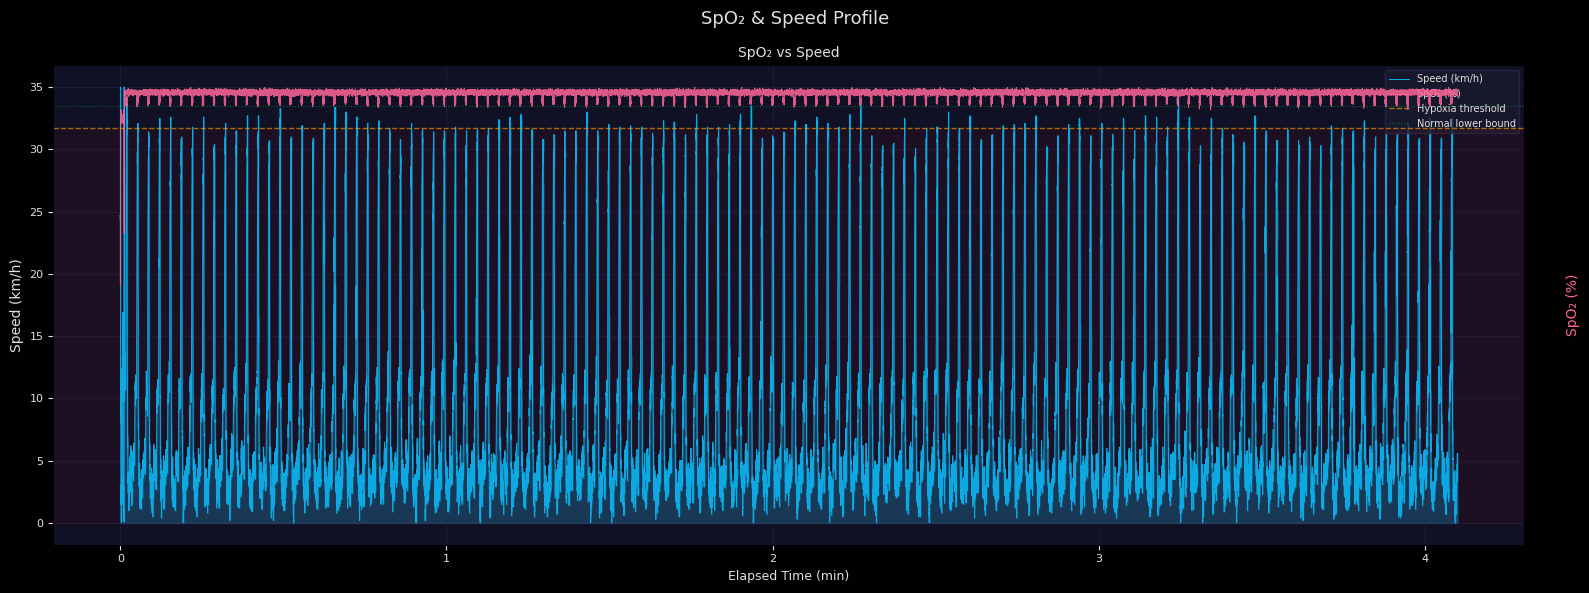

SpO₂ below 90% (hypoxic): 14 samples (0.0%)
SpO₂ at 95%+ (normal):   52717 samples (99.5%)
Min SpO₂: 54.0% | Max SpO₂: 99.2%


In [30]:
fig8, ax8 = plt.subplots(figsize=(16, 6), facecolor=DARK_BG)
fig8.suptitle('SpO\u2082 & Speed Profile', color=TEXT_COL, fontsize=13)

# Speed as filled area (left axis)
ax8.fill_between(t, spd, color='#00BFFF', alpha=0.25)
ax8.plot(t, spd, color='#00BFFF', linewidth=0.7, alpha=0.9, label='Speed (km/h)')
ax8.set_ylabel('Speed (km/h)', color='#00BFFF', fontsize=10)

# SpO2 on right axis
ax8r = ax8.twinx()
ax8r.plot(t, df['SpO2 (%)'].values, color='#FF6699', linewidth=0.7, alpha=0.85, label='SpO\u2082 (%)')
ax8r.set_ylabel('SpO\u2082 (%)', color='#FF6699', fontsize=10)

# Safety thresholds
ax8r.axhline(90, color='#FFAA00', linewidth=1.0, linestyle='--', alpha=0.6, label='Hypoxia threshold')
ax8r.axhline(95, color='#00CC44', linewidth=0.8, linestyle=':', alpha=0.4, label='Normal lower bound')

# Shade hypoxia zone
ax8r.axhspan(0, 90, color='#FF0000', alpha=0.05)

lines1, l1 = ax8.get_legend_handles_labels()
lines2, l2 = ax8r.get_legend_handles_labels()
ax8.legend(lines1 + lines2, l1 + l2, fontsize=7, loc='upper right',
           facecolor='#1a1a2e', edgecolor=GRID_COL, labelcolor=TEXT_COL)
style_ax(ax8, xlabel='Elapsed Time (min)', title='SpO\u2082 vs Speed')

plt.tight_layout()
plt.show()

# Count hypoxic events
hypoxic = (df['SpO2 (%)'] < 90).sum()
normal  = (df['SpO2 (%)'] >= 95).sum()
print(f'SpO\u2082 below 90% (hypoxic): {hypoxic} samples ({hypoxic/len(df)*100:.1f}%)')
print(f'SpO\u2082 at 95%+ (normal):   {normal} samples ({normal/len(df)*100:.1f}%)')
print(f'Min SpO\u2082: {df["SpO2 (%)"].min():.1f}% | Max SpO\u2082: {df["SpO2 (%)"].max():.1f}%')


---
## Plot 9 - Cumulative Distance & Pace Analysis

**What the plot shows:**  
The cumulative distance line shows how total distance builds across the session. Steeper sections represent faster movement, while flatter sections represent walking, standing, or recovery. The rolling-speed panel shows short-term pace changes.

**What it tells us about performance:**  
This plot separates volume from intensity. A player may cover modest total distance but still experience high stress if the distance is made up of repeated bursts. Sharp increases in distance show productive running phases, while plateaus reveal recovery periods. This helps coaches understand whether the session was continuous endurance work or repeated high-intensity interval work.


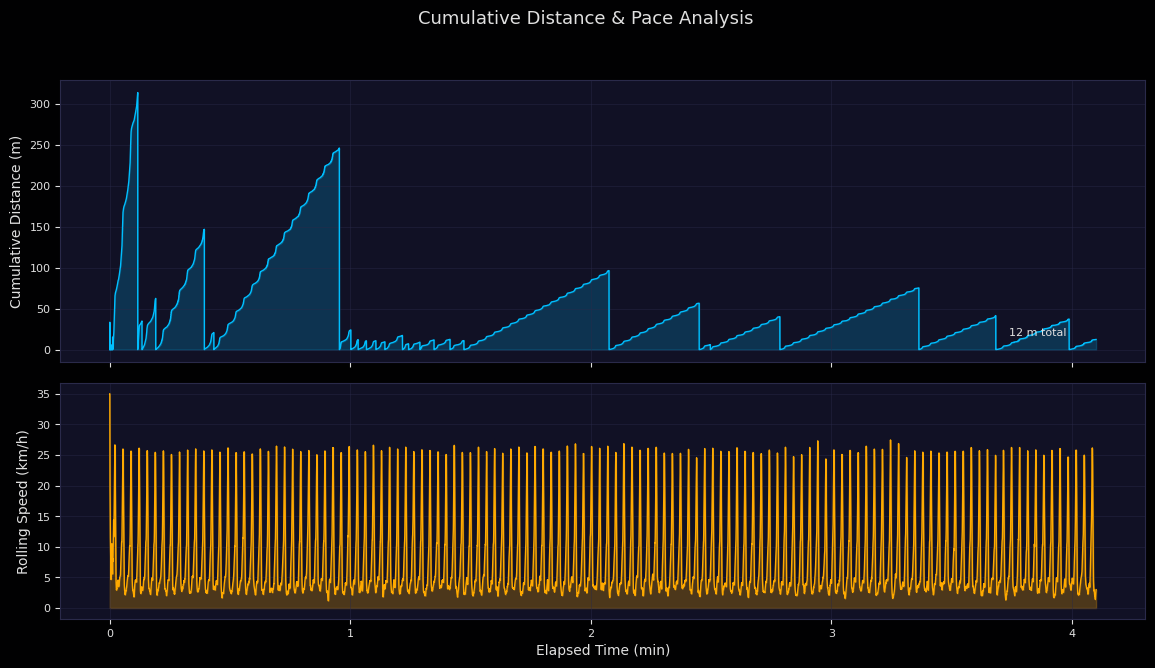

Total distance: 12.3 m
Session duration: 4.10 min
Avg pace: 0.2 km/h (including rest)


In [31]:
# --- Plot 9 theme fallbacks (supports out-of-order execution) ---
if 'DARK_BG' not in globals():
    DARK_BG = "#010102"
if 'PANEL_BG' not in globals():
    PANEL_BG = '#111125'
if 'TEXT_COL' not in globals():
    TEXT_COL = '#e0e0e0'
if 'GRID_COL' not in globals():
    GRID_COL = '#2a2a4a'
if 'style_ax' not in globals():
    def style_ax(ax, xlabel='', ylabel='', title=''):
        ax.set_facecolor(PANEL_BG)
        ax.tick_params(colors=TEXT_COL, labelsize=8)
        ax.xaxis.label.set_color(TEXT_COL)
        ax.yaxis.label.set_color(TEXT_COL)
        for spine in ax.spines.values():
            spine.set_edgecolor(GRID_COL)
        ax.grid(True, color=GRID_COL, linewidth=0.5, alpha=0.6)
        if xlabel: ax.set_xlabel(xlabel, color=TEXT_COL, fontsize=9)
        if ylabel: ax.set_ylabel(ylabel, color=TEXT_COL, fontsize=9)
        if title:  ax.set_title(title, color=TEXT_COL, fontsize=10, pad=6)
fig9, (a9a, a9b) = plt.subplots(2, 1, figsize=(14, 7), facecolor=DARK_BG,
                                 gridspec_kw={'height_ratios': [1.2, 1], 'hspace': 0.08})
fig9.suptitle('Cumulative Distance & Pace Analysis', color=TEXT_COL, fontsize=13)

# Cumulative distance
dist = df['Total Distance (m)'].values
a9a.fill_between(t, dist, color='#00BFFF', alpha=0.2)
a9a.plot(t, dist, color='#00BFFF', linewidth=1.0)
a9a.set_ylabel('Cumulative Distance (m)', color=TEXT_COL, fontsize=10)
a9a.text(t[-1] * 0.97, dist[-1] + 5, f'{dist[-1]:.0f} m total',
         color=TEXT_COL, fontsize=8, ha='right')
style_ax(a9a)
a9a.set_xticklabels([])

# Rolling speed (pace indicator)
win = 60  # ~6 s rolling window
rs = pd.Series(spd).rolling(win, min_periods=1).mean().values
a9b.fill_between(t, rs, color='#FFAA00', alpha=0.25)
a9b.plot(t, rs, color='#FFAA00', linewidth=1.0)
a9b.set_xlabel('Elapsed Time (min)', color=TEXT_COL, fontsize=10)
a9b.set_ylabel('Rolling Speed (km/h)', color=TEXT_COL, fontsize=10)
style_ax(a9b)

plt.tight_layout()
plt.show()

print(f'Total distance: {dist[-1]:.1f} m')
print(f'Session duration: {t[-1]:.2f} min')
print(f'Avg pace: {dist[-1] / (t[-1] * 60) * 3.6:.1f} km/h (including rest)')


❗ 1. You assumed this is cumulative distance
dist = df['Total Distance (m)'].values

👉 This is the core mistake.

From your plot:

Value resets multiple times
Ends at ~12.3 m (nonsense)

➡️ Therefore:

❌ This column is NOT cumulative distance
❗ 2. Your interpretation depends on that assumption
# **here is the better version

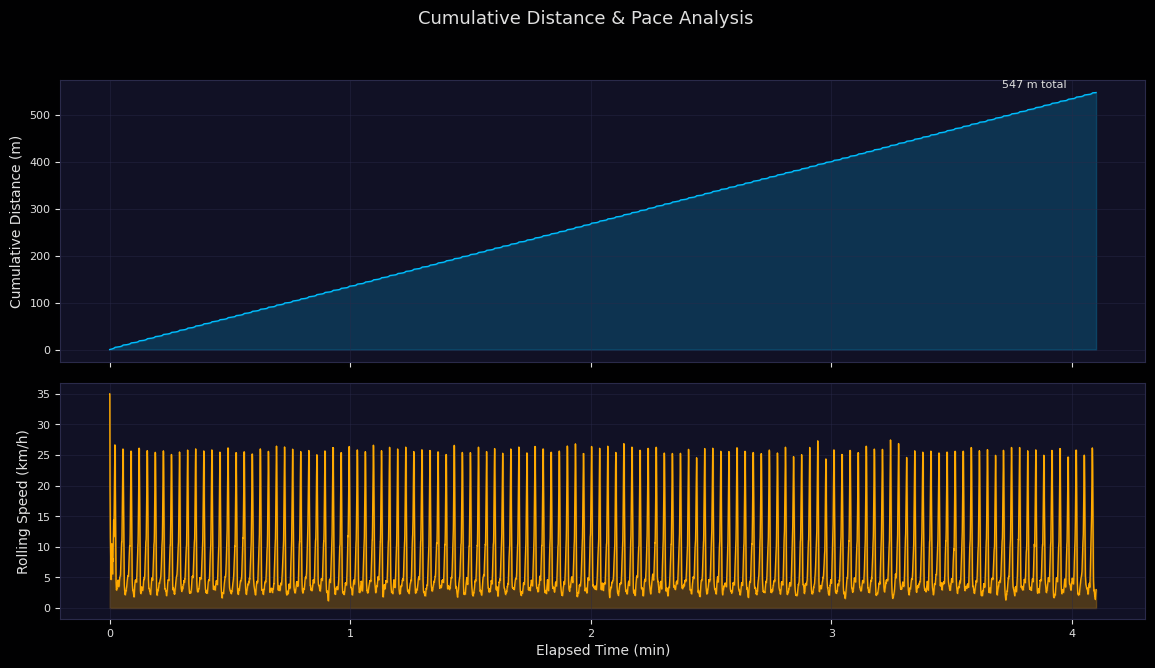

Total distance: 546.9 m
Session duration: 4.10 min
Average speed: 8.0 km/h


In [ ]:

t_sec = t * 60

# time deltas (s)
dt = np.diff(t_sec, prepend=t_sec[0])
dt[0] = 0  # first step = 0 to avoid artificial jump

# speed km/h → m/s
spd_ms = spd / 3.6

# integrate distance (m)
dist_true = np.cumsum(spd_ms * dt)


win = 60 # 
rs = pd.Series(spd).rolling(win, min_periods=1).mean().values

if 'DARK_BG' not in globals():
    DARK_BG = "#010102"
if 'PANEL_BG' not in globals():
    PANEL_BG = '#111125'
if 'TEXT_COL' not in globals():
    TEXT_COL = '#e0e0e0'
if 'GRID_COL' not in globals():
    GRID_COL = '#2a2a4a'
if 'style_ax' not in globals():
    def style_ax(ax, xlabel='', ylabel='', title=''):
        ax.set_facecolor(PANEL_BG)
        ax.tick_params(colors=TEXT_COL, labelsize=8)
        ax.xaxis.label.set_color(TEXT_COL)
        ax.yaxis.label.set_color(TEXT_COL)
        for spine in ax.spines.values():
            spine.set_edgecolor(GRID_COL)
        ax.grid(True, color=GRID_COL, linewidth=0.5, alpha=0.6)
        if xlabel: ax.set_xlabel(xlabel, color=TEXT_COL, fontsize=9)
        if ylabel: ax.set_ylabel(ylabel, color=TEXT_COL, fontsize=9)
        if title:  ax.set_title(title, color=TEXT_COL, fontsize=10, pad=6)
fig9, (a9a, a9b) = plt.subplots(
    2, 1, figsize=(14, 7), facecolor=DARK_BG,
    gridspec_kw={'height_ratios': [1.2, 1], 'hspace': 0.08}
)
fig9.suptitle('Cumulative Distance & Pace Analysis', color=TEXT_COL, fontsize=13)

# Cumulative distance (TRUE)
a9a.fill_between(t, dist_true, color='#00BFFF', alpha=0.2)
a9a.plot(t, dist_true, color='#00BFFF', linewidth=1.0)
a9a.set_ylabel('Cumulative Distance (m)', color=TEXT_COL, fontsize=10)
a9a.text(t[-1] * 0.97, dist_true[-1] * 1.02,
         f'{dist_true[-1]:.0f} m total', color=TEXT_COL, fontsize=8, ha='right')
style_ax(a9a)
a9a.set_xticklabels([])

# Rolling speed (pace indicator)
a9b.fill_between(t, rs, color='#FFAA00', alpha=0.25)
a9b.plot(t, rs, color='#FFAA00', linewidth=1.0)
a9b.set_xlabel('Elapsed Time (min)', color=TEXT_COL, fontsize=10)
a9b.set_ylabel('Rolling Speed (km/h)', color=TEXT_COL, fontsize=10)
style_ax(a9b)

plt.tight_layout()
plt.show()

# --- Summary metrics ---
total_distance_m = dist_true[-1]
duration_min = t[-1]
avg_speed_kmh = (total_distance_m / (duration_min * 60)) * 3.6  # m/s → km/h

print(f'Total distance: {total_distance_m:.1f} m')
print(f'Session duration: {duration_min:.2f} min')
print(f'Average speed: {avg_speed_kmh:.1f} km/h')

---
## Plot 10 - Heart Rate Recovery Analysis

This plot examines heart-rate recovery (HRR) following bursts identified from peaks in the speed signal, and the corresponding peak heart rate for each effort. HRR remains relatively consistent, mostly between ~50–65 BPM, indicating stable recovery across the session. Peak heart rate per burst varies within a narrow range (~155–175 BPM) without a clear upward trend, suggesting no evident cardiovascular drift. Together, these patterns indicate that the player maintains effective recovery between efforts and sustains repeated high-intensity actions without clear signs of accumulating physiological strain. Given the short duration and peak-detection method, these results should be interpreted as indicative of stable recovery rather than definitive evidence of overall fitness.

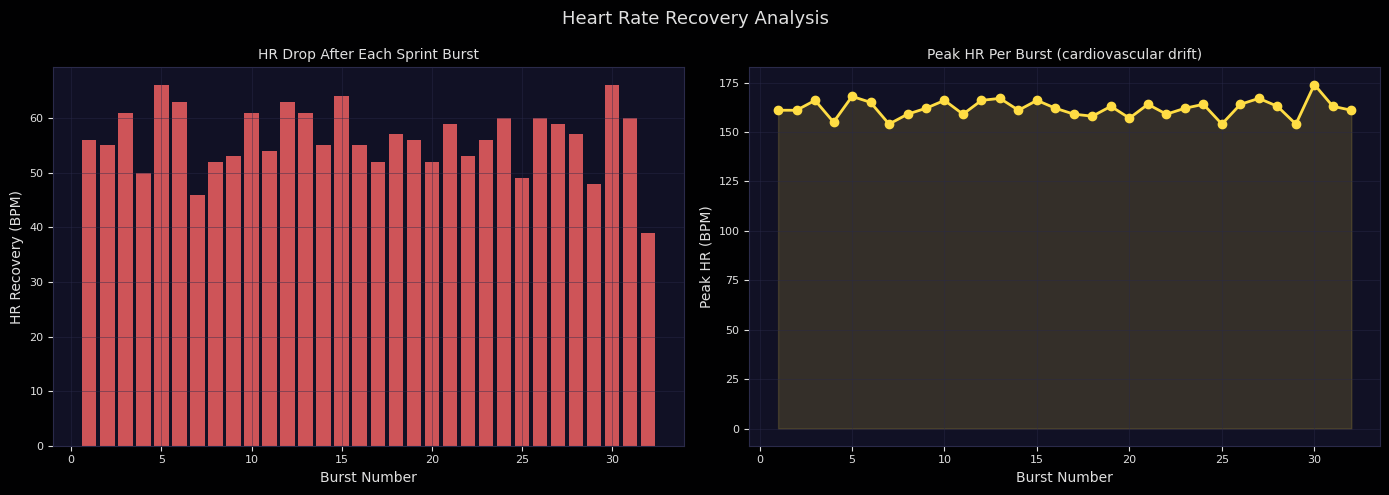

=== HEART RATE RECOVERY ===
 burst_num  peak_hr  trough_hr  hrr  time_min
         1      161        105   56  0.154850
         2      161        106   55  0.322933
         3      166        105   61  0.490397
         4      155        105   50  0.658402
         5      168        102   66  0.792977
         6      165        102   63  1.027844
         7      154        108   46  1.228506
         8      159        107   52  1.430949
         9      162        109   53  1.498043
        10      166        105   61  1.564750
        11      159        105   54  1.665429
        12      166        103   63  1.934578
        13      167        106   61  2.069076
        14      161        106   55  2.135705
        15      166        102   64  2.270667
        16      162        107   55  2.405009
        17      159        107   52  2.539274
        18      158        101   57  2.605749
        19      163        107   56  2.807727
        20      157        105   52  2.940522
      

In [32]:
# Detect recovery periods: find local maxima in speed (burst peaks) and subsequent HR drop
from scipy.signal import argrelextrema

# Find speed peaks (sprint bursts)
peak_idx = argrelextrema(spd, np.greater, order=500)[0]  # peaks with at least 50-sample gap

# For each peak, find the HR at peak and HR at the subsequent trough
recovery_data = []
for pk in peak_idx:
    # Look ahead for the next HR minimum (recovery trough)
    window_end = min(pk + 2000, len(df))  # look up to ~200 seconds ahead
    trough_idx = pk + np.argmin(hr[pk:window_end])
    if trough_idx > pk:
        hrr = hr[pk] - hr[trough_idx]  # HR drop during recovery
        recovery_data.append({
            'burst_num': len(recovery_data) + 1,
            'peak_hr': hr[pk],
            'trough_hr': hr[trough_idx],
            'hrr': hrr,
            'time_min': t[pk]
        })

recovery_df = pd.DataFrame(recovery_data)

if len(recovery_df) > 1:
    fig10, (ax10a, ax10b) = plt.subplots(1, 2, figsize=(14, 5), facecolor=DARK_BG)
    fig10.suptitle('Heart Rate Recovery Analysis', color=TEXT_COL, fontsize=13)

    # Left: HRR per burst number
    ax10a.bar(recovery_df['burst_num'], recovery_df['hrr'],
              color='#FF6666', edgecolor='none', alpha=0.8)
    ax10a.set_xlabel('Burst Number', color=TEXT_COL, fontsize=10)
    ax10a.set_ylabel('HR Recovery (BPM)', color=TEXT_COL, fontsize=10)
    ax10a.set_title('HR Drop After Each Sprint Burst', color=TEXT_COL, fontsize=10)
    style_ax(ax10a)

    # Right: Peak HR per burst (rising = accumulating fatigue)
    ax10b.plot(recovery_df['burst_num'], recovery_df['peak_hr'],
               color='#FFDD44', linewidth=2, marker='o', markersize=6)
    ax10b.fill_between(recovery_df['burst_num'], recovery_df['peak_hr'],
                        color='#FFDD44', alpha=0.15)
    ax10b.set_xlabel('Burst Number', color=TEXT_COL, fontsize=10)
    ax10b.set_ylabel('Peak HR (BPM)', color=TEXT_COL, fontsize=10)
    ax10b.set_title('Peak HR Per Burst (cardiovascular drift)', color=TEXT_COL, fontsize=10)
    style_ax(ax10b)
else:
    fig10, ax10 = plt.subplots(figsize=(10, 5), facecolor=DARK_BG)
    ax10.text(0.5, 0.5, 'Not enough recovery periods detected.',
              ha='center', va='center', fontsize=12, color=TEXT_COL,
              transform=ax10.transAxes)
    ax10.axis('off')
    recovery_df = pd.DataFrame()

plt.tight_layout()
plt.show()

if len(recovery_df) > 0:
    print('=== HEART RATE RECOVERY ===')
    print(recovery_df.to_string(index=False))
    if len(recovery_df) > 2:
        early_hrr = recovery_df['hrr'].iloc[:len(recovery_df)//2].mean()
        late_hrr = recovery_df['hrr'].iloc[len(recovery_df)//2:].mean()
        print(f'\nAvg early HRR:  {early_hrr:.1f} BPM')
        print(f'Avg late HRR:   {late_hrr:.1f} BPM')
        if late_hrr < early_hrr:
            print('Declining HRR -> accumulating fatigue detected')
        else:
            print('Stable/recovering HRR -> adequate recovery between bursts')


---
## Summary Statistics

In [16]:
print('=' * 55)
print('  SESSION SUMMARY — U20 Bangladesh National Team')
print('=' * 55)
print(f'  Total Samples          : {len(df):,}')
print(f'  Session Duration       : {t[-1]:.2f} min')
print(f'  Total Distance (GPS)   : {df["Total Distance (m)"].max():.1f} m')
print(f'  Max Speed (cleaned)    : {spd.max():.1f} km/h')
print(f'  Avg Speed              : {spd.mean():.1f} km/h')
print(f'  Avg Heart Rate         : {hr.mean():.0f} BPM')
print(f'  Peak Heart Rate        : {hr.max():.0f} BPM')
print(f'  Avg Acceleration       : {accel.mean():.1f} m/s²')
print(f'  Total Accel Events     : {int(accel_ev.max())}')
print(f'  Total Decel Events     : {int(decel_ev.max())}')
print(f'  Total Sprint Count     : {int(sprint_c.max())}')
print(f'  Cumulative PlayerLoad  : {pl_cum.max():.1f} AU')
print(f'  Avg Body Rotation      : {rot.mean():.1f} °/s')
print('=' * 55)

  SESSION SUMMARY — U20 Bangladesh National Team
  Total Samples          : 52,982
  Session Duration       : 4.10 min
  Total Distance (GPS)   : 313.6 m
  Max Speed (cleaned)    : 35.0 km/h
  Avg Speed              : 8.0 km/h
  Avg Heart Rate         : 133 BPM
  Peak Heart Rate        : 210 BPM
  Avg Acceleration       : 9.9 m/s²
  Total Accel Events     : 2670
  Total Decel Events     : 2469
  Total Sprint Count     : 18
  Cumulative PlayerLoad  : 207.6 AU
  Avg Body Rotation      : 21.7 °/s
